# Process Fixed Broadband Deployment CSV (NC/SC + Charlotte Region)

This notebook is built for large CSV processing using **chunked reads** to avoid memory crashes in VS Code.

Input file expected:
- `Data/Fixed_Broadband_Deployment_Data__June_2021_Status_V1_20260225.csv`

Outputs:
- `Data/output/fixed_broadband_charlotte_filtered.csv`
- `Data/output/fixed_broadband_charlotte_county_summary.csv`

In [1]:
from pathlib import Path
import json
import urllib.request

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

pd.set_option('display.max_columns', 120)
sns.set_theme(style='whitegrid')

In [2]:
# Paths
ROOT = Path.cwd()
if (ROOT / 'Data').exists():
    data_dir = ROOT / 'Data'
else:
    data_dir = ROOT.parent / 'Data'

input_csv = data_dir / 'Fixed_Broadband_Deployment_Data__June_2021_Status_V1_20260225.csv'
output_dir = data_dir / 'output'
output_dir.mkdir(parents=True, exist_ok=True)

assert input_csv.exists(), f'Missing input file: {input_csv}'
input_csv

WindowsPath('c:/Users/vparadka/Documents/GitHub/ui-map-app/Data/Fixed_Broadband_Deployment_Data__June_2021_Status_V1_20260225.csv')

In [3]:
# Charlotte-region county target list (10-county region; editable)
# NC: Anson, Cabarrus, Gaston, Iredell, Lincoln, Mecklenburg, Rowan, Union
# SC: Lancaster, York
target_counties = {
    '37007': 'Anson County, NC',
    '37025': 'Cabarrus County, NC',
    '37071': 'Gaston County, NC',
    '37097': 'Iredell County, NC',
    '37109': 'Lincoln County, NC',
    '37119': 'Mecklenburg County, NC',
    '37159': 'Rowan County, NC',
    '37179': 'Union County, NC',
    '45057': 'Lancaster County, SC',
    '45091': 'York County, SC'
}

target_states = {'NC', 'SC'}
target_county_fips = set(target_counties.keys())

# Columns to keep from the source file
use_cols = [
    'Provider ID',
    'Provider Name',
    'State',
    'Census Block FIPS Code',
    'Technology Code',
    'Consumer',
    'Business',
    'Max Advertised Downstream Speed (mbps)',
    'Max Advertised Upstream Speed (mbps)'
]

# Read in chunks to avoid out-of-memory issues
chunksize = 1_000_000
filtered_parts = []

for i, chunk in enumerate(pd.read_csv(input_csv, usecols=use_cols, chunksize=chunksize, low_memory=False), start=1):
    # Clean + normalize key fields
    chunk['State'] = chunk['State'].astype(str).str.strip()
    chunk['Census Block FIPS Code'] = (
        chunk['Census Block FIPS Code']
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('.0', '', regex=False)
        .str.strip()
        .str.zfill(15)
    )

    # County FIPS = first 5 digits of census block FIPS
    chunk['county_fips'] = chunk['Census Block FIPS Code'].str[:5]

    # Filter to NC/SC and Charlotte county list
    m = chunk['State'].isin(target_states) & chunk['county_fips'].isin(target_county_fips)
    part = chunk.loc[m].copy()

    if not part.empty:
        part['county_name'] = part['county_fips'].map(target_counties)
        filtered_parts.append(part)

    if i % 5 == 0:
        print(f'Processed {i} chunks... matched rows so far: {sum(len(x) for x in filtered_parts):,}')

filtered_df = pd.concat(filtered_parts, ignore_index=True) if filtered_parts else pd.DataFrame(columns=use_cols + ['county_fips', 'county_name'])
print(f'Final filtered rows: {len(filtered_df):,}')
filtered_df.head()

Processed 5 chunks... matched rows so far: 22,183
Processed 10 chunks... matched rows so far: 44,701
Processed 15 chunks... matched rows so far: 67,442
Processed 20 chunks... matched rows so far: 90,001
Processed 25 chunks... matched rows so far: 112,343
Processed 30 chunks... matched rows so far: 134,879
Processed 35 chunks... matched rows so far: 157,371
Processed 40 chunks... matched rows so far: 179,807
Processed 45 chunks... matched rows so far: 202,336
Processed 50 chunks... matched rows so far: 224,717
Processed 55 chunks... matched rows so far: 247,224
Processed 60 chunks... matched rows so far: 269,804
Processed 65 chunks... matched rows so far: 292,436
Processed 70 chunks... matched rows so far: 314,859
Processed 75 chunks... matched rows so far: 337,160
Final filtered rows: 350,884


,Provider ID,Provider Name,State,Census Block FIPS Code,Technology Code,Consumer,Max Advertised Downstream Speed (mbps),Max Advertised Upstream Speed (mbps),Business,county_fips,county_name
0,77860,"Windstream Concord Telephone, Inc",NC,371590514001015,10,1,4,1,1,37159,"Rowan County, NC"
1,80632,GCI Communication Corp.,SC,450910619003088,60,0,0,0,1,45091,"York County, SC"
2,76499,"BellSouth Telecommunications, Inc.",NC,370970607022008,12,1,25,5,0,37097,"Iredell County, NC"
3,76770,"Comporium, Inc.",SC,450910612022030,43,1,"1,000",35,1,45091,"York County, SC"
4,76499,"BellSouth Telecommunications, Inc.",SC,450910615023007,11,1,18,1.5,0,45091,"York County, SC"


In [4]:
# Normalize numeric fields
for col in ['Max Advertised Downstream Speed (mbps)', 'Max Advertised Upstream Speed (mbps)', 'Consumer', 'Business', 'Technology Code']:
    filtered_df[col] = pd.to_numeric(filtered_df[col], errors='coerce')

# Persist filtered data
filtered_out = output_dir / 'fixed_broadband_charlotte_filtered.csv'
filtered_df.to_csv(filtered_out, index=False)

# County-level summary
summary = (
    filtered_df
    .groupby(['county_fips', 'county_name', 'State'], dropna=False)
    .agg(
        records=('county_fips', 'size'),
        providers=('Provider ID', 'nunique'),
        avg_down_mbps=('Max Advertised Downstream Speed (mbps)', 'mean'),
        median_down_mbps=('Max Advertised Downstream Speed (mbps)', 'median'),
        avg_up_mbps=('Max Advertised Upstream Speed (mbps)', 'mean'),
        median_up_mbps=('Max Advertised Upstream Speed (mbps)', 'median')
    )
    .reset_index()
    .sort_values(['State', 'county_name'])
)

summary_out = output_dir / 'fixed_broadband_charlotte_county_summary.csv'
summary.to_csv(summary_out, index=False)

print('Saved:', filtered_out)
print('Saved:', summary_out)
summary

Saved: c:\Users\vparadka\Documents\GitHub\ui-map-app\Data\output\fixed_broadband_charlotte_filtered.csv
Saved: c:\Users\vparadka\Documents\GitHub\ui-map-app\Data\output\fixed_broadband_charlotte_county_summary.csv


,county_fips,county_name,State,records,providers,avg_down_mbps,median_down_mbps,avg_up_mbps,median_up_mbps
0,37007,"Anson County, NC",NC,11338,17,32.227754,10.0,11.813444,2.0
1,37025,"Cabarrus County, NC",NC,31420,29,37.733871,25.0,15.095877,3.0
2,37071,"Gaston County, NC",NC,40804,22,36.968942,25.0,9.372307,3.0
3,37097,"Iredell County, NC",NC,35957,32,64.091315,25.0,11.570151,3.0
4,37109,"Lincoln County, NC",NC,12430,20,32.225102,25.0,7.526055,3.0
5,37119,"Mecklenburg County, NC",NC,99205,51,40.626402,25.0,8.788070,3.0
6,37159,"Rowan County, NC",NC,29454,23,32.380675,18.0,10.561883,3.0
7,37179,"Union County, NC",NC,34654,29,34.528054,18.0,12.279656,3.0
8,45057,"Lancaster County, SC",SC,20103,17,27.295624,11.0,6.180200,1.3
9,45091,"York County, SC",SC,35519,26,26.385527,11.0,6.443768,3.0


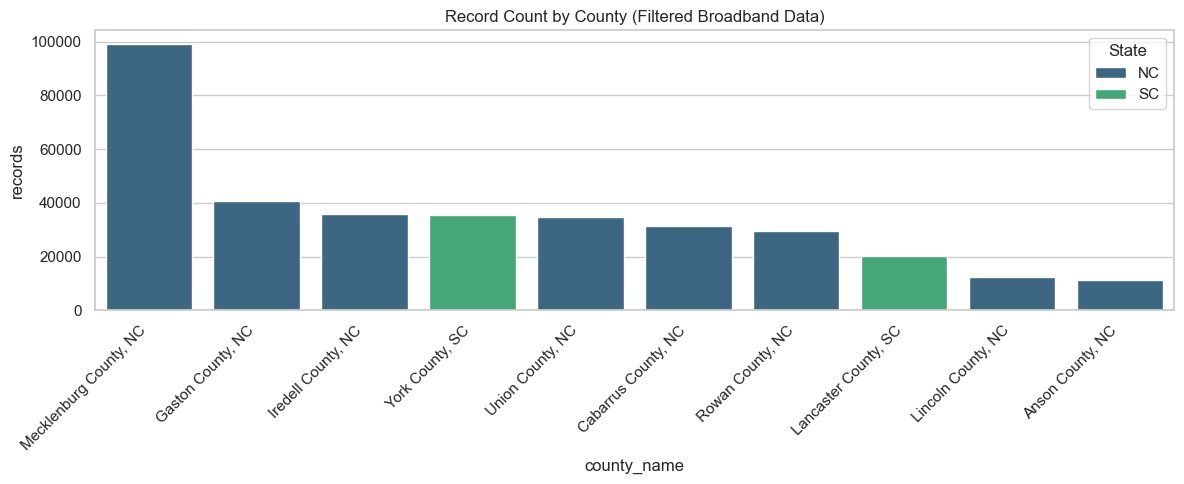

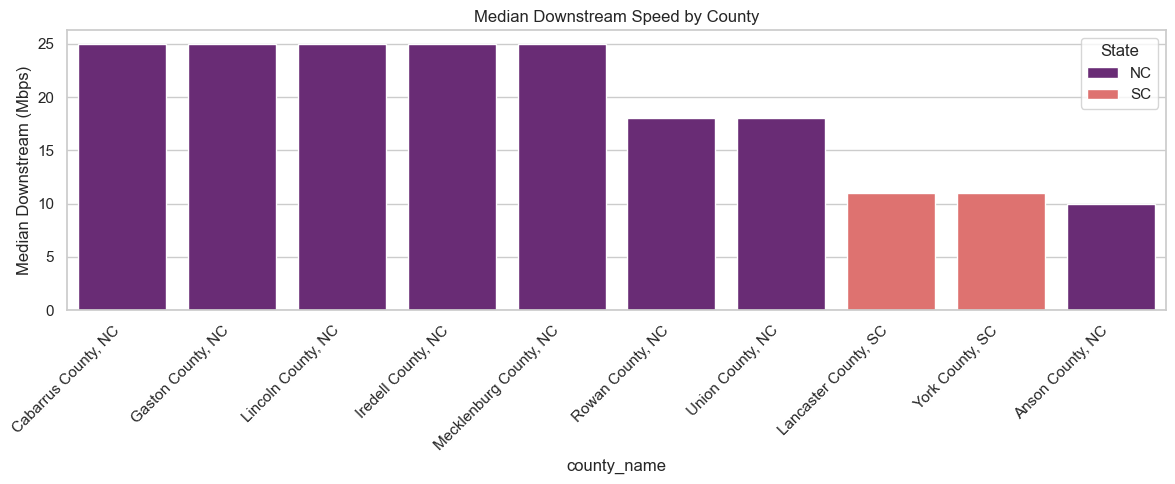

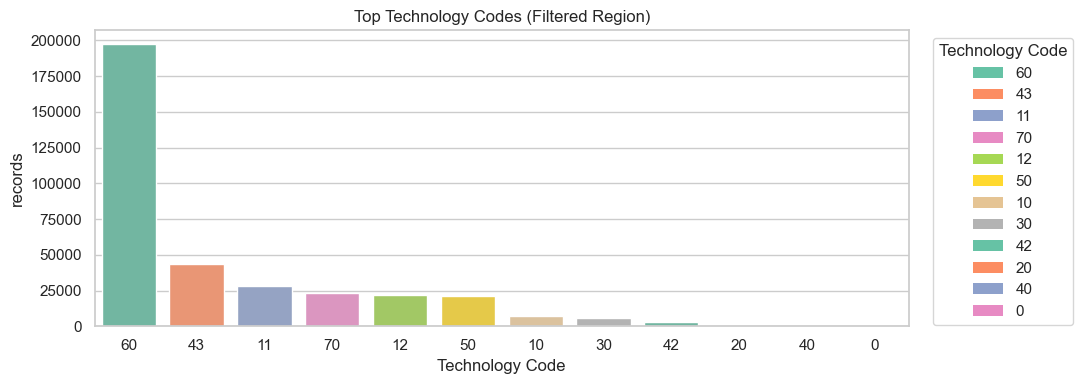

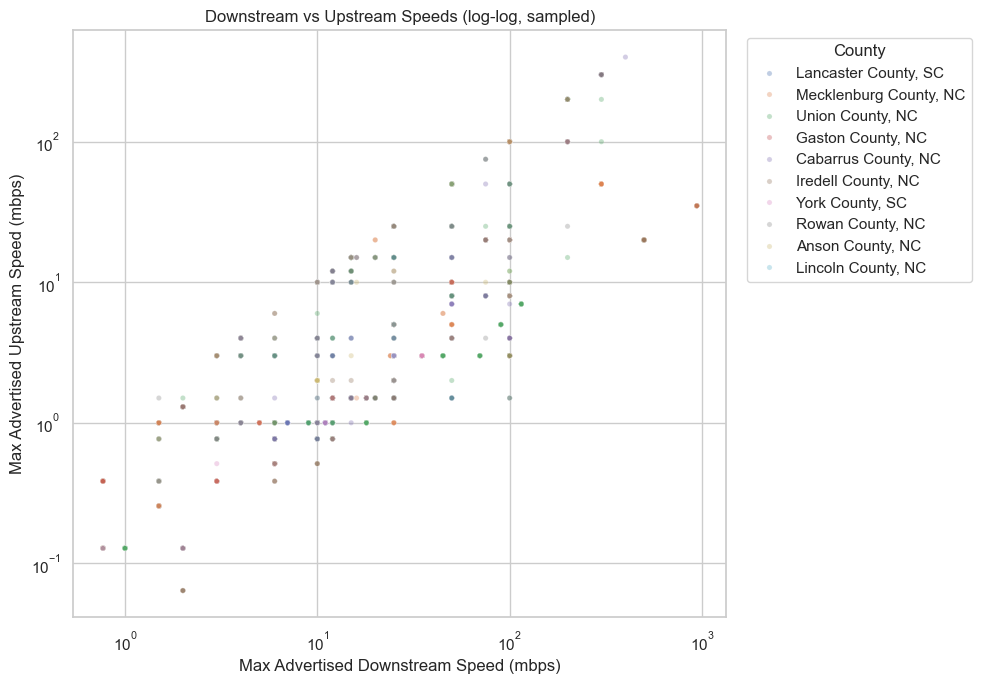

In [5]:
if filtered_df.empty:
    print('No rows found for selected counties. Check county list and input schema.')
else:
    # 1) Record count by county (with state legend)
    plt.figure(figsize=(12, 5))
    order = summary.sort_values('records', ascending=False)['county_name']
    sns.barplot(
        data=summary,
        x='county_name',
        y='records',
        hue='State',
        order=order,
        dodge=False,
        palette='viridis'
    )
    plt.xticks(rotation=45, ha='right')
    plt.title('Record Count by County (Filtered Broadband Data)')
    plt.legend(title='State', loc='upper right')
    plt.tight_layout()
    plt.show()

    # 2) Median downstream speed by county (with state legend)
    plt.figure(figsize=(12, 5))
    order2 = summary.sort_values('median_down_mbps', ascending=False)['county_name']
    sns.barplot(
        data=summary,
        x='county_name',
        y='median_down_mbps',
        hue='State',
        order=order2,
        dodge=False,
        palette='magma'
    )
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Median Downstream (Mbps)')
    plt.title('Median Downstream Speed by County')
    plt.legend(title='State', loc='upper right')
    plt.tight_layout()
    plt.show()

    # 3) Top technology codes in region (explicit color legend)
    tech = (filtered_df['Technology Code']
            .value_counts(dropna=False)
            .rename_axis('Technology Code')
            .reset_index(name='records'))

    top_tech = tech.head(12).copy()
    top_tech['Technology Code'] = top_tech['Technology Code'].astype(str)

    palette = sns.color_palette('Set2', n_colors=len(top_tech))
    color_map = dict(zip(top_tech['Technology Code'], palette))

    plt.figure(figsize=(11, 4))
    ax = sns.barplot(
        data=top_tech,
        x='Technology Code',
        y='records',
        hue='Technology Code',
        dodge=False,
        palette=color_map,
        legend=False
    )
    handles = [Patch(facecolor=color_map[tc], edgecolor='none', label=tc) for tc in top_tech['Technology Code']]
    ax.legend(handles=handles, title='Technology Code', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.title('Top Technology Codes (Filtered Region)')
    plt.tight_layout()
    plt.show()

    # 4) Downstream vs Upstream (sample for readability, with county legend)
    sample = filtered_df[['Max Advertised Downstream Speed (mbps)', 'Max Advertised Upstream Speed (mbps)', 'county_name']].dropna()
    if len(sample) > 50000:
        sample = sample.sample(50000, random_state=42)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=sample,
        x='Max Advertised Downstream Speed (mbps)',
        y='Max Advertised Upstream Speed (mbps)',
        hue='county_name',
        alpha=0.35,
        s=14
    )
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Downstream vs Upstream Speeds (log-log, sampled)')
    plt.legend(title='County', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [6]:
!pip install nbformat>=4.2.0

# 5) County map visualization (choropleth)
if filtered_df.empty:
    print('No data to map.')
else:
    try:
        import plotly.express as px
    except ImportError:
        print('Plotly is not installed. Run Cell 8, then restart kernel and rerun from Cell 2.')
    else:
        map_df = summary.copy()
        map_df['county_fips'] = map_df['county_fips'].astype(str).str.zfill(5)

        # US county boundaries geojson
        county_geojson_url = 'https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json'

        fig = px.choropleth(
            map_df,
            geojson=county_geojson_url,
            locations='county_fips',
            color='median_down_mbps',
            color_continuous_scale='Viridis',
            scope='usa',
            hover_name='county_name',
            hover_data={
                'State': True,
                'records': ':,',
                'providers': ':,',
                'median_down_mbps': ':.2f',
                'avg_down_mbps': ':.2f',
                'county_fips': False
            },
            title='Charlotte Region Counties: Median Downstream Speed (Mbps)'
        )

        fig.update_geos(fitbounds='locations', visible=False)
        fig.update_layout(
            margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
            coloraxis_colorbar_title='Median Down (Mbps)'
        )

        try:
            fig.show()
        except Exception as ex:
            html_out = output_dir / 'fixed_broadband_charlotte_map_median_down.html'
            fig.write_html(html_out, include_plotlyjs='cdn')
            print('Inline Plotly render unavailable in this kernel.')
            print(f'Saved interactive map to: {html_out}')
            print(f'Render error: {ex}')

In [7]:
# Install once per kernel if Plotly is missing
try:
    import plotly  # noqa: F401
    print('Plotly already installed')
except ImportError:
    %pip install plotly -q

Plotly already installed


## Notes

- If you need a different county set, edit `target_counties` in Cell 4.
- If the source file changes column names, update `use_cols` in Cell 4.
- For even larger files, lower `chunksize` (e.g., `500_000`) to reduce memory pressure.